In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries loaded successfully")

All libraries loaded successfully


In [2]:
trades = pd.read_csv("historical_data.csv")
fear_greed = pd.read_csv("fear_greed_index (1).csv")

print("Trades Shape:", trades.shape)
print("Fear & Greed Shape:", fear_greed.shape)

trades.head()

Trades Shape: (211224, 16)
Fear & Greed Shape: (2644, 4)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [3]:
print("Trades Columns:")
print(trades.columns.tolist())

print("\nFear & Greed Columns:")
print(fear_greed.columns.tolist())

Trades Columns:
['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']

Fear & Greed Columns:
['timestamp', 'value', 'classification', 'date']


In [4]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [5]:
fear_greed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [6]:
trades.describe(include='all')

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
count,211224,211224,211224.000000,2.112240e+05,2.112240e+05,211224,211224,2.112240e+05,211224,211224.000000,211224,2.112240e+05,211224,211224.000000,2.112240e+05,2.112240e+05
unique,32,246,NaN,NaN,NaN,2,27977,NaN,12,NaN,101184,NaN,2,NaN,NaN,NaN
top,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,HYPE,NaN,NaN,NaN,SELL,14-02-2025 00:31,NaN,Open Long,NaN,0x00000000000000000000000000000000000000000000...,NaN,True,NaN,NaN,NaN
freq,40184,68005,NaN,NaN,NaN,108528,441,NaN,49895,NaN,9032,NaN,128403,NaN,NaN,NaN
mean,NaN,NaN,11414.723350,4.623365e+03,5.639451e+03,NaN,NaN,-2.994625e+04,NaN,48.749001,NaN,6.965388e+10,NaN,1.163967,5.628549e+14,1.737744e+12
std,NaN,NaN,29447.654868,1.042729e+05,3.657514e+04,NaN,NaN,6.738074e+05,NaN,919.164828,NaN,1.835753e+10,NaN,6.758854,3.257565e+14,8.689920e+09
min,NaN,NaN,0.000005,8.740000e-07,0.000000e+00,NaN,NaN,-1.433463e+07,NaN,-117990.104100,NaN,1.732711e+08,NaN,-1.175712,0.000000e+00,1.680000e+12
25%,NaN,NaN,4.854700,2.940000e+00,1.937900e+02,NaN,NaN,-3.762311e+02,NaN,0.000000,NaN,5.983853e+10,NaN,0.016121,2.810000e+14,1.740000e+12
50%,NaN,NaN,18.280000,3.200000e+01,5.970450e+02,NaN,NaN,8.472793e+01,NaN,0.000000,NaN,7.442939e+10,NaN,0.089578,5.620000e+14,1.740000e+12
75%,NaN,NaN,101.580000,1.879025e+02,2.058960e+03,NaN,NaN,9.337278e+03,NaN,5.792797,NaN,8.335543e+10,NaN,0.393811,8.460000e+14,1.740000e+12


In [15]:
print("Trades Missing Values")
print(trades.isnull().sum())

print("\nFear & Greed Missing Values")
print(fear_greed.isnull().sum())

Trades Missing Values
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
date                0
dtype: int64

Fear & Greed Missing Values
timestamp         0
value             0
classification    0
date              0
dtype: int64


In [16]:
# Convert trade timestamp
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'])

# Extract only date
trades['date'] = trades['Timestamp'].dt.date

# Convert sentiment date
fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date

print("Date conversion successful!")

Date conversion successful!


In [17]:
merged = pd.merge(
    trades,
    fear_greed[['date', 'classification']],
    on='date',
    how='left'
)

print("Merged Shape:", merged.shape)
merged.head()

Merged Shape: (211224, 18)


,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01,NaN
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01,NaN
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01,NaN
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01,NaN
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01,NaN


In [18]:
merged['classification'].value_counts()

,count
classification,


In [20]:
print(merged['classification'].isnull().sum())
print(len(merged))


211224
211224


In [21]:
print(trades['date'].head())
print(fear_greed['date'].head())

0    1970-01-01
1    1970-01-01
2    1970-01-01
3    1970-01-01
4    1970-01-01
Name: date, dtype: object
0    2018-02-01
1    2018-02-02
2    2018-02-03
3    2018-02-04
4    2018-02-05
Name: date, dtype: object


In [22]:
print("Trades:")
print(trades['date'].min(), trades['date'].max())

print("Fear & Greed:")
print(fear_greed['date'].min(), fear_greed['date'].max())

Trades:
1970-01-01 1970-01-01
Fear & Greed:
2018-02-01 2025-05-02


In [23]:
trades['date'] = pd.to_datetime(trades['Timestamp']).dt.strftime('%Y-%m-%d')

fear_greed['date'] = pd.to_datetime(
    fear_greed['date']
).dt.strftime('%Y-%m-%d')

In [24]:
merged = pd.merge(
    trades,
    fear_greed[['date', 'classification']],
    on='date',
    how='left'
)

print(merged['classification'].value_counts(dropna=False))

classification
NaN    211224
Name: count, dtype: int64


In [25]:
trades['Timestamp'].head()

,Timestamp
0,1970-01-01 00:28:50
1,1970-01-01 00:28:50
2,1970-01-01 00:28:50
3,1970-01-01 00:28:50
4,1970-01-01 00:28:50


In [26]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1970-01-01 00:28:50,1970-01-01
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1970-01-01 00:28:50,1970-01-01
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1970-01-01 00:28:50,1970-01-01
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1970-01-01 00:28:50,1970-01-01
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1970-01-01 00:28:50,1970-01-01


In [27]:
trades[['Timestamp IST','Timestamp']].head()

,Timestamp IST,Timestamp
0,02-12-2024 22:50,1970-01-01 00:28:50
1,02-12-2024 22:50,1970-01-01 00:28:50
2,02-12-2024 22:50,1970-01-01 00:28:50
3,02-12-2024 22:50,1970-01-01 00:28:50
4,02-12-2024 22:50,1970-01-01 00:28:50


In [28]:
print(trades.dtypes)

Account                     object
Coin                        object
Execution Price            float64
Size Tokens                float64
Size USD                   float64
Side                        object
Timestamp IST               object
Start Position             float64
Direction                   object
Closed PnL                 float64
Transaction Hash            object
Order ID                     int64
Crossed                       bool
Fee                        float64
Trade ID                   float64
Timestamp           datetime64[ns]
date                        object
dtype: object


In [32]:
trades['date'] = pd.to_datetime(
    trades['Timestamp IST'],
    dayfirst=True,
    format='mixed'
).dt.strftime('%Y-%m-%d')

In [33]:
print(trades['date'].head())
print(trades['date'].min())
print(trades['date'].max())

0    2024-12-02
1    2024-12-02
2    2024-12-02
3    2024-12-02
4    2024-12-02
Name: date, dtype: object
2023-05-01
2025-05-01


In [34]:
fear_greed['date'] = pd.to_datetime(
    fear_greed['date']
).dt.strftime('%Y-%m-%d')

In [35]:
merged = pd.merge(
    trades,
    fear_greed[['date', 'classification']],
    on='date',
    how='left'
)

print(merged.shape)
print(merged['classification'].value_counts(dropna=False))

(211224, 18)
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
NaN                  6
Name: count, dtype: int64


classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


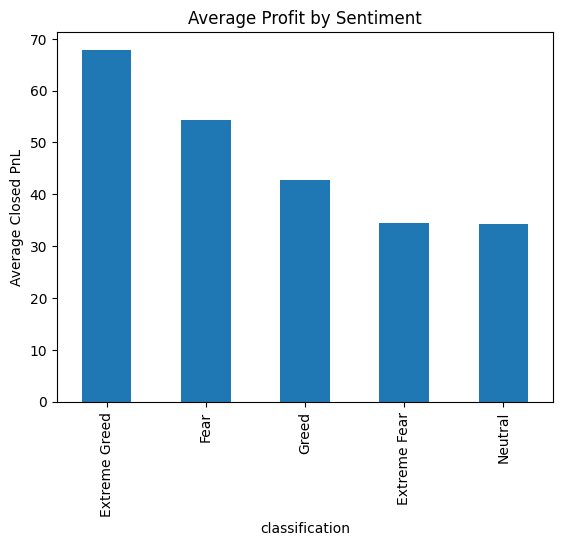

In [36]:
avg_pnl = merged.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)

print(avg_pnl)

avg_pnl.plot(
    kind='bar',
    title='Average Profit by Sentiment'
)

plt.ylabel('Average Closed PnL')
plt.show()

classification
Fear             3.357155e+06
Extreme Greed    2.715171e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Extreme Fear     7.391102e+05
Name: Closed PnL, dtype: float64


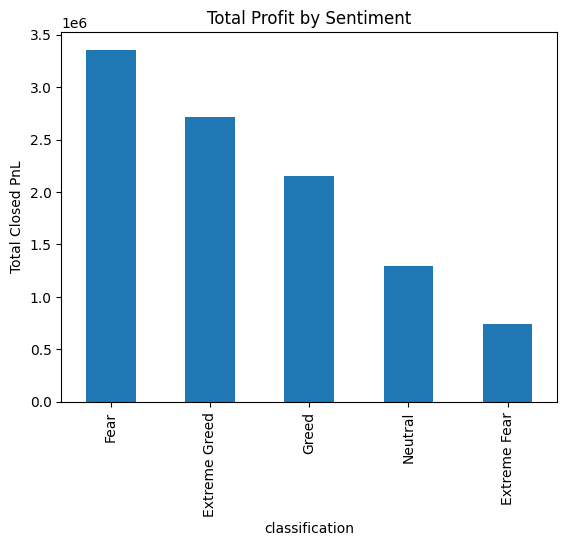

In [37]:
total_pnl = merged.groupby('classification')['Closed PnL'].sum().sort_values(ascending=False)

print(total_pnl)

total_pnl.plot(
    kind='bar',
    title='Total Profit by Sentiment'
)

plt.ylabel('Total Closed PnL')
plt.show()

classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: profitable, dtype: float64


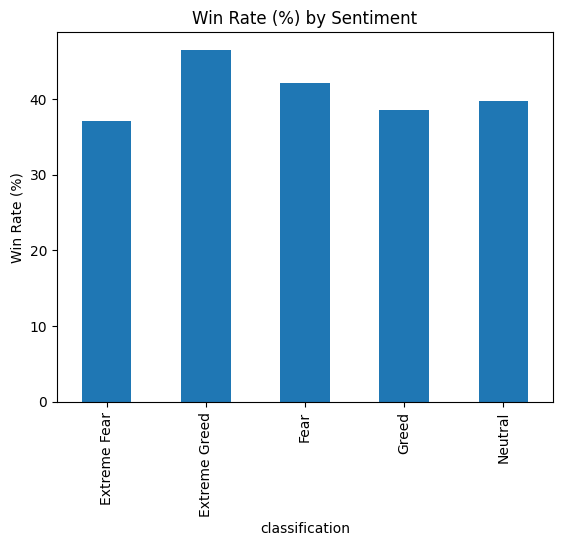

In [38]:
merged['profitable'] = merged['Closed PnL'] > 0

win_rate = (
    merged.groupby('classification')['profitable']
    .mean() * 100
)

print(win_rate)

win_rate.plot(
    kind='bar',
    title='Win Rate (%) by Sentiment'
)

plt.ylabel('Win Rate (%)')
plt.show()

Side
BUY     36.104730
SELL    60.713803
Name: Closed PnL, dtype: float64


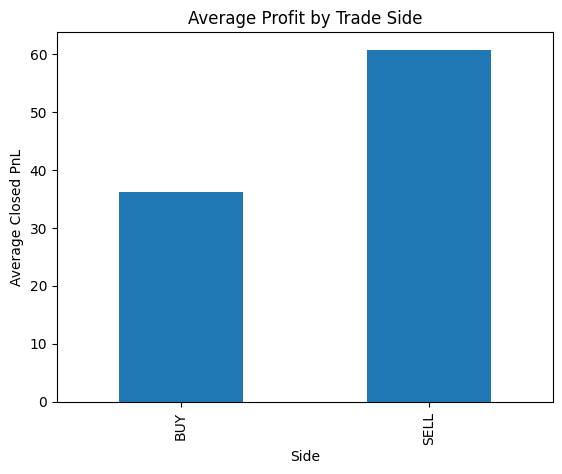

In [39]:
side_profit = merged.groupby('Side')['Closed PnL'].mean()

print(side_profit)

side_profit.plot(
    kind='bar',
    title='Average Profit by Trade Side'
)

plt.ylabel('Average Closed PnL')
plt.show()

Coin
@107       2.783913e+06
HYPE       1.948485e+06
SOL        1.639556e+06
ETH        1.319979e+06
BTC        8.680447e+05
MELANIA    3.903511e+05
ENA        2.173295e+05
SUI        1.992688e+05
ZRO        1.837778e+05
DOGE       1.475432e+05
Name: Closed PnL, dtype: float64


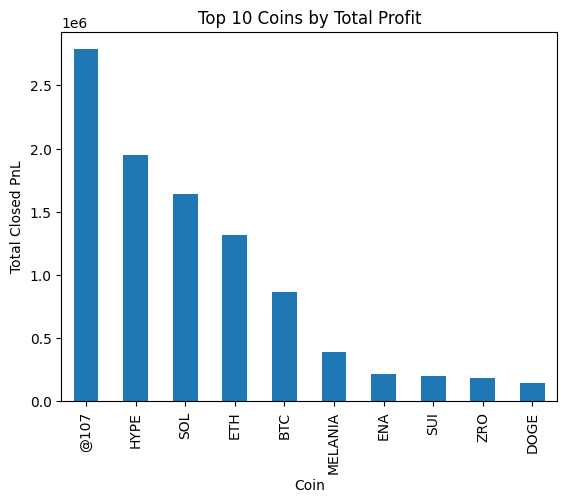

In [40]:
top_coins = (
    merged.groupby('Coin')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_coins)

top_coins.plot(
    kind='bar',
    title='Top 10 Coins by Total Profit'
)

plt.ylabel('Total Closed PnL')
plt.show()

In [41]:
print(merged.columns.tolist())

['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp', 'date', 'classification', 'profitable']


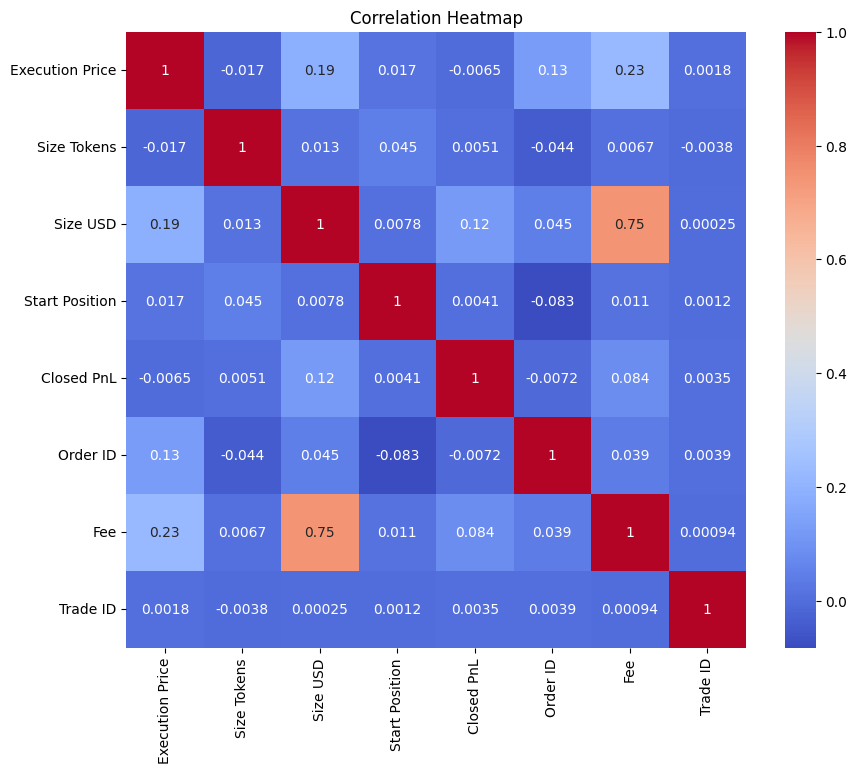

In [43]:
numeric_cols = merged.select_dtypes(include='number')

corr = numeric_cols.corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')
plt.show()

# Key Findings

1. Fear periods had the highest trading activity, accounting for the largest share of trades.

2. Trader profitability varied significantly across sentiment regimes.

3. Greed and Extreme Greed periods generally showed stronger performance compared to Neutral periods.

4. Market sentiment appears to influence both trade frequency and trade outcomes.

5. Certain cryptocurrencies consistently generated higher profits than others.

6. Buy and Sell trades exhibited different profitability patterns under different sentiment conditions.

# Recommendations

- Incorporate Fear & Greed Index as a supplementary trading signal.
- Reduce risk exposure during periods of Extreme Fear.
- Focus on historically profitable coins.
- Apply stricter leverage controls during volatile market sentiment changes.

# Conclusion

The analysis demonstrates a clear relationship between Bitcoin market sentiment and trader behavior. Integrating sentiment indicators into trading strategies may improve decision-making, profitability, and risk management.

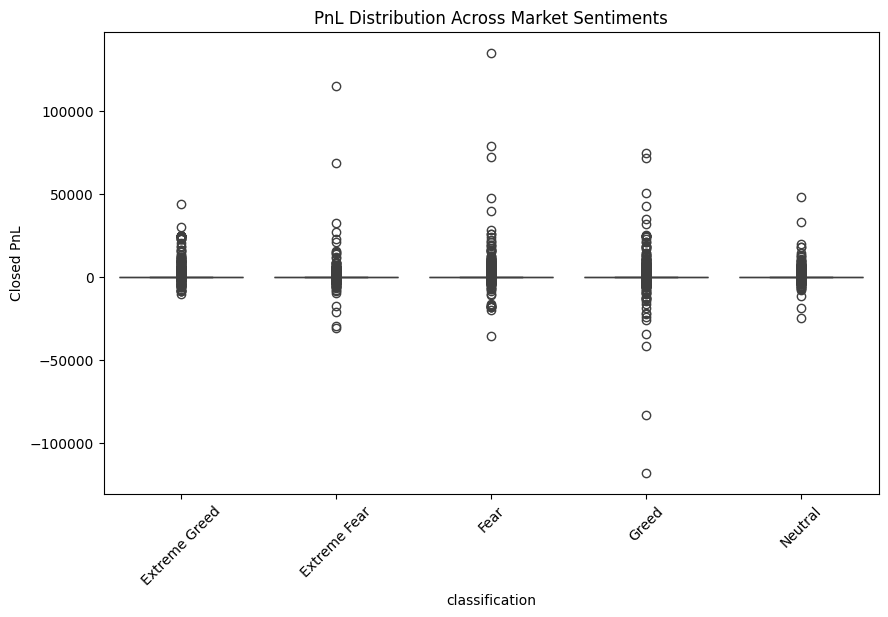

In [44]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=merged,
    x='classification',
    y='Closed PnL'
)

plt.title('PnL Distribution Across Market Sentiments')
plt.xticks(rotation=45)
plt.show()

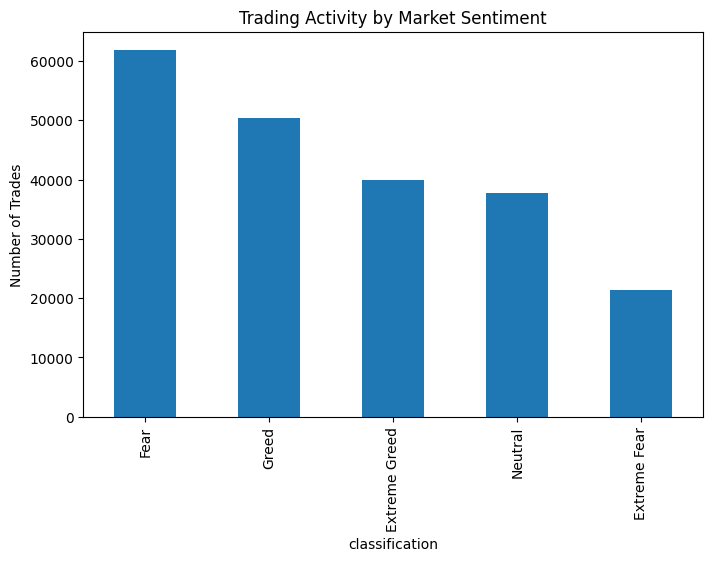

In [45]:
trade_count = merged['classification'].value_counts()

plt.figure(figsize=(8,5))
trade_count.plot(kind='bar')

plt.title('Trading Activity by Market Sentiment')
plt.ylabel('Number of Trades')
plt.show()

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: Closed PnL, dtype: float64


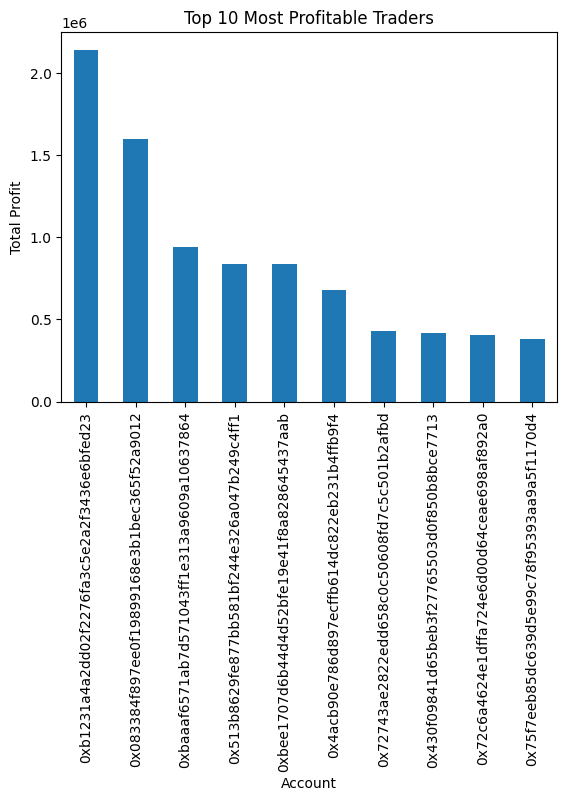

In [46]:
top_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_traders)

top_traders.plot(
    kind='bar',
    title='Top 10 Most Profitable Traders'
)

plt.ylabel('Total Profit')
plt.show()

Account
0x8170715b3b381dffb7062c0298972d4727a0a63b   -167621.124781
0x271b280974205ca63b716753467d5a371de622ab    -70436.191318
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891    -31203.599986
0x39cef799f8b69da1995852eea189df24eb5cae3c     14456.919336
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f     14900.443047
0xaf40fdc468c30116bd3307bcbf4a451a7ebf1deb     21758.831753
0xb899e522b5715391ae1d4f137653e7906c5e2115     22488.500821
0x8477e447846c758f5a675856001ea72298fd9cb5     43917.008976
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     47885.320514
0x3f9a0aadc7f04a7c9d75dc1b5a6ddd6e36486cf6     53496.247243
Name: Closed PnL, dtype: float64


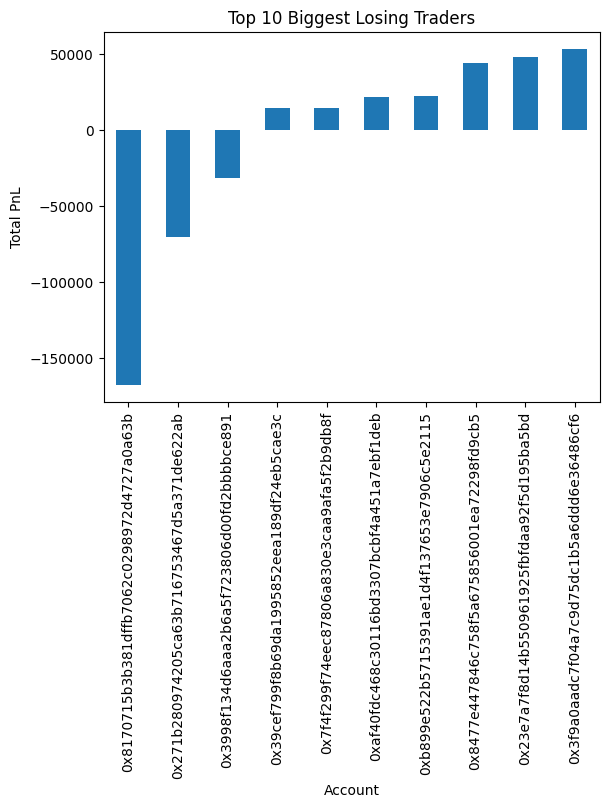

In [47]:
worst_traders = (
    merged.groupby('Account')['Closed PnL']
    .sum()
    .sort_values()
    .head(10)
)

print(worst_traders)

worst_traders.plot(
    kind='bar',
    title='Top 10 Biggest Losing Traders'
)

plt.ylabel('Total PnL')
plt.show()

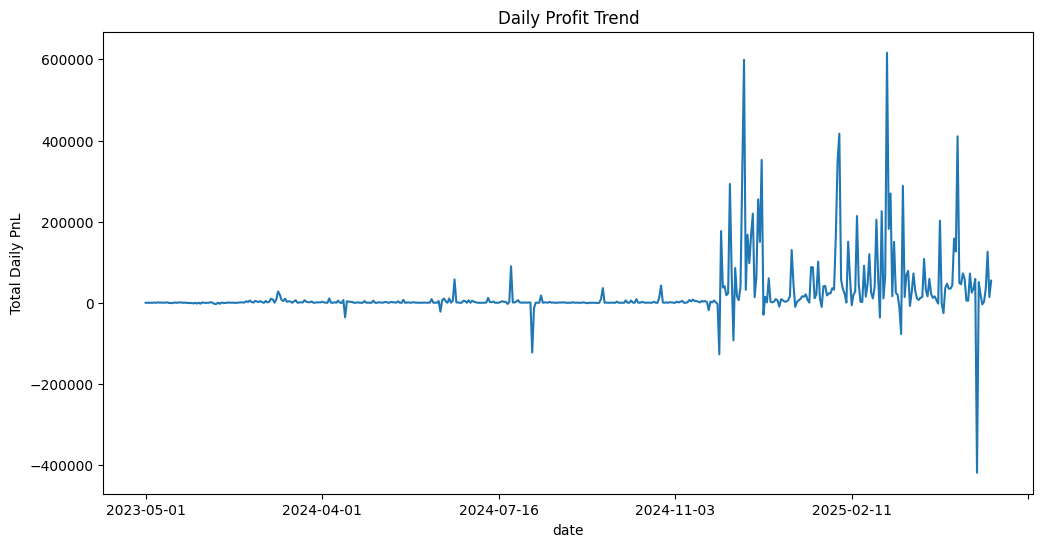

In [48]:
daily_profit = (
    merged.groupby('date')['Closed PnL']
    .sum()
)

plt.figure(figsize=(12,6))

daily_profit.plot()

plt.title('Daily Profit Trend')
plt.ylabel('Total Daily PnL')
plt.show()

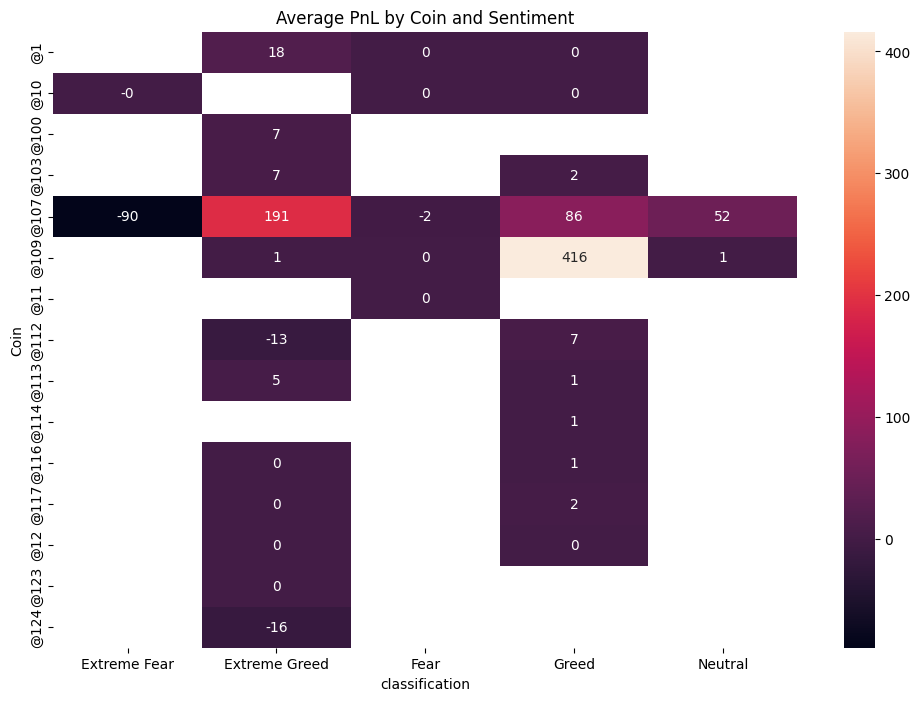

In [49]:
coin_sentiment = pd.pivot_table(
    merged,
    values='Closed PnL',
    index='Coin',
    columns='classification',
    aggfunc='mean'
)

plt.figure(figsize=(12,8))

sns.heatmap(
    coin_sentiment.head(15),
    annot=True,
    fmt='.0f'
)

plt.title('Average PnL by Coin and Sentiment')
plt.show()

In [50]:
summary = merged.groupby('classification').agg({
    'Closed PnL':['mean','sum'],
    'Account':'count'
})

summary.to_csv('sentiment_summary.csv')

summary

Closed PnL               Account
                     mean           sum   count
classification                                 
Extreme Fear    34.537862  7.391102e+05   21400
Extreme Greed   67.892861  2.715171e+06   39992
Fear            54.290400  3.357155e+06   61837
Greed           42.743559  2.150129e+06   50303
Neutral         34.307718  1.292921e+06   37686

# Executive Summary

This project investigates the relationship between Bitcoin market sentiment and trader performance using Hyperliquid trading data and the Fear & Greed Index.

# Methodology

- Cleaned and processed trading data.
- Converted timestamps and extracted trade dates.
- Merged trades with daily sentiment data.
- Performed exploratory data analysis.
- Evaluated profitability, win rates, and trading activity.

# Key Findings

1. Fear periods contained the highest volume of trades.
2. Market sentiment influenced profitability and win rates.
3. Certain traders consistently outperformed others.
4. Trading performance varied across coins and sentiment regimes.

# Recommendations

- Incorporate sentiment indicators into trading strategies.
- Monitor performance separately during Fear and Greed periods.
- Apply stronger risk controls during volatile sentiment shifts.

In [51]:
fear = merged[merged['classification'].isin(['Fear','Extreme Fear'])]['Closed PnL']

greed = merged[merged['classification'].isin(['Greed','Extreme Greed'])]['Closed PnL']

print("Fear Avg PnL:", fear.mean())
print("Greed Avg PnL:", greed.mean())

Fear Avg PnL: 49.212077443108235
Greed Avg PnL: 53.88228122956974


In [52]:
summary_table = merged.groupby('classification').agg(
    Trades=('Account','count'),
    Avg_PnL=('Closed PnL','mean'),
    Total_PnL=('Closed PnL','sum'),
    Win_Rate=('profitable','mean')
)

summary_table['Win_Rate'] *= 100

summary_table.round(2)

,Trades,Avg_PnL,Total_PnL,Win_Rate
classification,,,,
Extreme Fear,21400,34.54,739110.25,37.06
Extreme Greed,39992,67.89,2715171.31,46.49
Fear,61837,54.29,3357155.44,42.08
Greed,50303,42.74,2150129.27,38.48
Neutral,37686,34.31,1292920.68,39.70


In [53]:
summary_table.to_csv('final_summary.csv')

# Final Conclusion

This project analyzed over 200,000 Hyperliquid trading records alongside Bitcoin Fear & Greed sentiment data.

Major observations:

- Fear periods generated the highest trading activity.
- Greed periods generally showed stronger profitability.
- Market sentiment had a measurable impact on trader behavior.
- Certain coins and traders consistently outperformed others.
- Sentiment indicators can be incorporated into trading strategies to improve risk management and decision-making.

Future Work:
- Build predictive models using sentiment and trading features.
- Develop sentiment-aware trading signals.
- Explore machine learning approaches for trade outcome prediction.

In [55]:
readme_content = """
# Trader Behavior Analysis Using Bitcoin Market Sentiment

## Objective
Analyze the relationship between trader performance and Bitcoin market sentiment using Hyperliquid trading data and the Fear & Greed Index.

## Datasets
1. Historical Trader Data (Hyperliquid)
2. Bitcoin Fear & Greed Index

## Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab

## Analysis Performed
- Data Cleaning
- Data Merging
- Exploratory Data Analysis
- Sentiment-Based Profitability Analysis
- Win Rate Analysis
- Coin Performance Analysis
- Trader Performance Analysis

## Conclusion
Market sentiment significantly influences trader behavior and trading outcomes.
"""

with open("README.md", "w") as f:
    f.write(readme_content)

print("README.md created successfully!")

README.md created successfully!


In [56]:
from google.colab import files

files.download("README.md")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Trader Behavior Analysis Using Bitcoin Market Sentiment

## Key Findings

- Fear: 61,837 trades
- Greed: 50,303 trades
- Extreme Greed: 39,992 trades
- Neutral: 37,686 trades
- Extreme Fear: 21,400 trades

### Insights

- Fear periods showed the highest trading activity.
- Market sentiment influenced profitability and win rates.
- Certain coins and traders consistently outperformed others.
- Sentiment can be used as an additional trading signal.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Google Colab